In [154]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("/home/jvierstra/proj/vinson")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [66]:
import pandas as pd
import numpy as np
import pickle
import configparser

from genome_tools.data.anndata import read_zarr_backed

In [6]:
nmf_config_file = "/net/seq/data2/projects/sabramov/SuperIndex/hotspot3/w_babachi_new.v23/embeddings/NMF/latest/nmf_config.ini"

config = configparser.ConfigParser()
config.read(nmf_config_file)

<Section: NMF>

In [7]:
dnase_adata = read_zarr_backed(config["NMF"]["anndata"])

In [68]:
labels_df = dnase_adata.obs.groupby("extended_annotation").filter(lambda x: len(x) >= 5)[
    [
        "extended_annotation",
         "pathological_state"
    ]
].rename(
    columns={
        "extended_annotation": "cell_type", 
        "pathological_state": "disease_state"
    }
)

#Merge brain regions
labels_df["cell_type"] = labels_df["cell_type"].cat.add_categories(["Brain"])
brain_region = labels_df["cell_type"].isin(["Cerebral cortex", "Basal ganglia", "Limbic system"])
labels_df["cell_type"] = labels_df["cell_type"].where(~brain_region, "Brain")

/tmp/ipykernel_43869/3978552857.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  labels_df = dnase_adata.obs.groupby("extended_annotation").filter(lambda x: len(x) >= 5)[


In [73]:
with open("/home/aabisheva/public_html/motif_data/cluster_matrices.pkl", "rb") as f:
    data = pickle.load(f)
    embedding = data["human_cluster_median"].T
    embedding.index.rename("ag_id", inplace=True)
    embedding.columns.rename("motif_cluster", inplace=True)
    # embedding = np.log(motif_props_human + 1e-5).apply(zscore_normalization, axis=0)[dnase_anndata.obs_names].values

def zscore_normalization(x, eta=1e-5):
    x = np.log(x + eta)
    return (x - x.mean()) / x.std()

normed_embedding = embedding.apply(zscore_normalization, axis=1)
normed_embedding = normed_embedding.loc[labels_df.index]

In [155]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

embed_train, embed_valid, labels_train, labels_valid = train_test_split(
    normed_embedding,
    labels_df,
    test_size=0.2,
    stratify=labels_df.cell_type,
    random_state=0
)

In [156]:
from vinson.datasets.cell_classifier import EncoderDataset

encoders = {
    col: LabelEncoder().fit(labels_df[col]) for col in labels_df.columns
}

ds_train = EncoderDataset(embed_train, labels_train, encoders=encoders)
ds_valid = EncoderDataset(embed_valid, labels_valid, encoders=encoders)

In [157]:
import torch
from torch.utils.data import DataLoader

train_dataloader = DataLoader(ds_train, batch_size=32, shuffle=True)
valid_dataloader = DataLoader(ds_valid, batch_size=32)

In [158]:
from vinson.models.cell_classifier import CellAndDiseaseStateClassifierModel

model = CellAndDiseaseStateClassifierModel(
    normed_embedding.shape[1],
    n_cell_types=len(encoders["cell_type"].classes_),
    n_disease_states=len(encoders["disease_state"].classes_)
)

In [159]:
import lightning as L

trainer = L.Trainer(
    max_epochs=50,
    accelerator="cpu"
)

trainer.fit(model, train_dataloader, valid_dataloader)

/home/jvierstra/.local/miniconda3/envs/tf-2.13.0/lib/python3.9/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/jvierstra/.local/miniconda3/envs/tf-2.13.0/lib ...
Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name               | Type             | Params | Mode 
----------------------------------------------------------------
0 | trunk              | EmbeddingMLP     | 22.9 K | train
1 | head_cell_type     | Linear           | 3.1 K  | train
2 | head_disease_state | Linear           | 130    | train
3 | loss_fn            | CrossEntropyLoss | 0      | train
-----

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=50` reached.


In [197]:
labels_cell_type, labels_disease_state = [], []
p_cell_type, p_disease_state = [], []

with torch.no_grad():
    for batch in valid_dataloader:
        X = batch["embed"]
        y_cell_type = batch["cell_type"]
        y_disease_state = batch["disease_state"]
        _y_cell_type, _y_disease_state = model(X) 

        labels_cell_type.append(y_cell_type.cpu().numpy())
        labels_disease_state.append(y_disease_state.cpu().numpy())

        p_cell_type.append(torch.softmax(_y_cell_type, dim=-1).cpu().numpy())
        p_disease_state.append(torch.softmax(_y_disease_state, dim=-1).cpu().numpy())

labels_cell_type = np.concatenate(labels_cell_type)
labels_disease_state = np.concatenate(labels_disease_state)

p_cell_type = np.vstack(p_cell_type)
p_disease_state = np.vstack(p_disease_state)

In [202]:
labels_cell_type_ohe = np.eye(len(encoders["cell_type"].classes_))[labels_cell_type]
labels_disease_state_ohe = np.eye(len(encoders["disease_state"].classes_))[labels_disease_state]

In [225]:
from sklearn.metrics import precision_recall_curve

i = 33

cell_type = encoders["cell_type"].classes_[i]

precision, recall, thresholds = precision_recall_curve(labels_cell_type_ohe[:, i], p_cell_type[:, i])

Text(0.5, 1.0, 'Muscle')

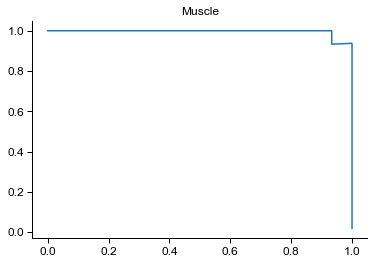

In [226]:
import matplotlib.pyplot as plt
plt.plot(recall, precision)
plt.title(cell_type)